In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("muratkokludataset/date-fruit-datasets")

print("Path to dataset files:", path)

100%|██████████| 408k/408k [00:00<00:00, 33.9MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/muratkokludataset/date-fruit-datasets/versions/1


In [3]:
# prompt: import libraries for ml project

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


In [4]:
df=pd.read_excel(path+'/Date_Fruit_Datasets/Date_Fruit_Datasets.xlsx')
df

,AREA,PERIMETER,MAJOR_AXIS,MINOR_AXIS,ECCENTRICITY,EQDIASQ,SOLIDITY,CONVEX_AREA,EXTENT,ASPECT_RATIO,...,KurtosisRR,KurtosisRG,KurtosisRB,EntropyRR,EntropyRG,EntropyRB,ALLdaub4RR,ALLdaub4RG,ALLdaub4RB,Class
0,422163,2378.9080,837.8484,645.6693,0.6373,733.1539,0.9947,424428,0.7831,1.2976,...,3.2370,2.9574,4.2287,-59191263232,-50714214400,-39922372608,58.7255,54.9554,47.8400,BERHI
1,338136,2085.1440,723.8198,595.2073,0.5690,656.1464,0.9974,339014,0.7795,1.2161,...,2.6228,2.6350,3.1704,-34233065472,-37462601728,-31477794816,50.0259,52.8168,47.8315,BERHI
2,526843,2647.3940,940.7379,715.3638,0.6494,819.0222,0.9962,528876,0.7657,1.3150,...,3.7516,3.8611,4.7192,-93948354560,-74738221056,-60311207936,65.4772,59.2860,51.9378,BERHI
3,416063,2351.2100,827.9804,645.2988,0.6266,727.8378,0.9948,418255,0.7759,1.2831,...,5.0401,8.6136,8.2618,-32074307584,-32060925952,-29575010304,43.3900,44.1259,41.1882,BERHI
4,347562,2160.3540,763.9877,582.8359,0.6465,665.2291,0.9908,350797,0.7569,1.3108,...,2.7016,2.9761,4.4146,-39980974080,-35980042240,-25593278464,52.7743,50.9080,42.6666,BERHI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
893,255403,1925.3650,691.8453,477.1796,0.7241,570.2536,0.9785,261028,0.7269,1.4499,...,2.2423,2.3704,2.7202,-25296416768,-19168882688,-18473392128,49.0869,43.0422,42.4153,SOGAY
894,365924,2664.8230,855.4633,551.5447,0.7644,682.5752,0.9466,386566,0.6695,1.5510,...,3.4109,3.5805,3.9910,-31605219328,-21945366528,-19277905920,46.8086,39.1046,36.5502,SOGAY
895,254330,1926.7360,747.4943,435.6219,0.8126,569.0545,0.9925,256255,0.7240,1.7159,...,2.2759,2.5090,2.6951,-22242772992,-19594921984,-17592152064,44.1325,40.7986,40.9769,SOGAY
896,238955,1906.2679,716.6485,441.8297,0.7873,551.5859,0.9604,248795,0.6954,1.6220,...,2.6769,2.6874,2.7991,-26048595968,-21299822592,-19809978368,51.2267,45.7162,45.6260,SOGAY


In [5]:
pip install summarytools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 34.4 MB/s eta 0:00:00


In [6]:
import summarytools
from summarytools import dfSummary
dfSummary(df)

No,Variable,Stats / Values,Freqs / (% of Valid),Graph,Missing
1,AREA[int64],Mean (sd) : 298295.2 (107245.2)min < med < max:1987.0 < 319833.0 < 546063.0IQR (CV) : 175625.0 (2.8),897 distinct values,"<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKoAAABGCAYAAABc8A97AAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjAsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvlHJYcgAAAAlwSFlzAAAPYQAAD2EBqD+naQAAAsJJREFUeJzt3buO2lAQgOE54bIHiGwQEnS0FJFSUPIQedg8QgoeYMUb0CGBBYJAuJgUUaJF2uwGH06Ysf6v9+Lilw3sjHGXy0UA7T48+gSAf1F99AngmnOuISL1gD9xuFwuu3udjxaEqohzrtHtdr8kSdIp+jfW63XmnPtatlgJVZd6kiSd8Xi8S9N0f+vBq9XKTyaTzmKxqIsIoSKuNE33vV7ve8HDG3c9GSX4MAUTCBUmECpMIFSYQKgwgVBhAqHCBEKFCYQKEwgVJhAqTCBUmECoMIHpqZI5n881EUmcc0UOVzt0Taglst1ua8fj8fNgMKhUKpWb51k1D12rDjVwLUPt1SGWw+FQ9d43R6PRvt/vZ7ccq33oWm2ooWsZmq8OsbVaraKD12qHrtWGKgFrGY++OgTcCZI8z2v3Pp8y0ByqiAStZTzk6hByJzgej/58Pn/a7/ffRKToKkopqQ/VoMJ3gtls1plOp83T6VSJdXJWEWokRe4EWZapfY/4aHzhDxMIFSYQKkwgVJhAqDCBUGECocIEQoUJhAoTCBUmECpMIFSYwFDKXzBTqguhvoKZUn0I9XXMlCpT2lAD14aTPM9raZpmzJTqUMpQQ9eGuX3rU8pQQ9aGRbh9a1TKUH8rujbM7VufUoeK2wS+rxeJ+NAPQoWIhL+vF4n70A9ChYiEv6+P/dAPQsWVgMcBiUR86Af/64cJhAoTCBUmECpMIFSYQKgwgVBhAqHCBEKFCYQKE6L+CzXw53dYksMf0UIN/fkdpuzxUswrauEFORGm7HEt+vRU0Z/fYcoeL/FhCiYQKkwgVJjAhD/uJnA58M3FQELFXYQuB763GPhuqM45LyJPt76w/PrCvrparXyBY2Wz2XgRke126+fzefN/HfvI17Z63iIiy+Xyo/e+ORwOXbvd/nHLsbvd7un5+fnNxcCf0tl/ePEImvcAAAAASUVORK5CYII="">",0(0.0%)
2,PERIMETER[float64],Mean (sd) : 2057.7 (410.0)min < med < max:911.8 < 2196.3 < 2812.0IQR (CV) : 663.6 (5.0),898 distinct values,"<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKoAAABGCAYAAABc8A97AAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjAsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvlHJYcgAAAAlwSFlzAAAPYQAAD2EBqD+naQAAAsNJREFUeJzt3b9u2lAUgPFzISDzR7YQLWwsHSt1YOQh+rB9hCLxBAxZOrEhIWSEGwtju0szVJUgvtcO9zjfb84VlvLFVsjJwZRlKYDvOo++AOAtnh59AaiXMWYgIn3L45eyLF/qvJ66EGqLGGMG0+n0exiGE5vzp9PpaIz54WOshNou/TAMJ6vV6iWKorTKwTiOg81mMzkcDn0RIVQ0L4qidDab/bY4Oqj9YmrCL1NQgVChAqFCBUKFCoQKFQgVKhAqVCBUqECoUIFQoQKhQgVChQqEChUIFSoQKlQgVKhAqFCBUKECoUIFQoUKhAoVCBUqECpUIFSoQKhQgVChAit9POO4jS8siqJX5/X4glA94rqNL8uyIM/zr2ma/hQRm91T3iJUv1hv4xMR2e12k+12O7xer12bF8/zvCcioTHG5rhIg/tVCdVDttv4jsej9Ta+JEl6WZZ9WywW3W63W/mHRKTZ/aqEChERuVwuT0EQDJfLZTqfz49Vzze9X5VQ8Y/RaGS7W1Wkwf2qvD0FFQgVKhAqVCBUqECoUIFQoQKhQgWv30dt68clojpvQ23zxyWiOm9DlRZ/XCKq8zlUEbEf0MjzPBRPJ4FQnfeh2vB9EgjVtTLUOiaB1uv17HA4fDLGnCwuoSMihcW51k7ou2plqK9sJ4Fc7sh5nveSJPkyHo9/dTqdrMrZNk/ou2p1qLZc7sh/p+w/L5fLZ8uz1hP6bUaoN9jckV+n7F3O4n/8ZQoqECpUIFSoQKhQgVChAqFCBUKFCoQKFQgVKjT6lylWKH4sjkvWbo5VNhYqKxQ/FtfRyntjlU3eUR+6QhHvy2WQ5y3/kXE3VIfHd1gURS+KouN7r1DE4zgsWbv5/b4Zqsvjm0c36nTvjmr9+ObRjTo1Po+aJEmw3++HVc+dz+fA9rzL2Ue+ttbrdj0fx3Fw72v+AJV/m8toz8GUAAAAAElFTkSuQmCC"">",0(0.0%)
3,MAJOR_AXIS[float64],Mean (sd) : 750.8 (144.1)min < med < max:336.7 < 791.4 < 1222.7IQR (CV) : 217.6 (5.2),898 distinct values,"<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKoAAABGCAYAAABc8A97AAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjAsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvlHJYcgAAAAlwSFlzAAAPYQAAD2EBqD+naQAAApJJREFUeJzt3UuO2kAUQNFX4Wc+soWQYMYGImXA0IvIYrOEHrACdsAMCSEjnHYwhTMioqN0OlRhuZ5zz7waD64t3NTHVFUlQOg+NX0BwL/oNn0BbWSMGYpI33H4uaqq12deTxsQ6pMZY4az2exrHMdTl/HH4/FgjPlGrG8R6vP14ziepmn6miRJ8cjALMui9Xo93e/3fREh1DuEWpMkSYr5fP7dYejw6RfTArxMQQVChQqEChUIFSoQKlQgVKhAqFCBUKECoUIFQoUKhAoVCBUqECpUIFSoQKhQgVChAqFCBUKFCoQKFQgVKhAqVCBUqMBy6cBYa3siEhtjXP9EK3daIdSA5HneK8vyy3K57HQ6nYc2r7hp604rhBqQ8/ncjaJotFqtisVicXh0fJt3WiHUAI3HY9ddVkRautMKL1NQgVChAqFCBUKFCoQKFQgVKhAqVCBUqECoUCHoX6Y4Bgc3wYba9DE4HjdJfL1eey6fifcFG6o0eAyOz01SlmVkrf1cFMWLiLj+Xo/fhByqiLgfg2OtjcV9Xmc8mUzmaZoeH71JttvtdLPZjC6XS8flg/FnwYfqwnde5+2pOBgMXh69SQ6HQytnLzWtlaH6zuvkqRieVoZ64zqvk6diePg/KlQgVKhAqFCBUKECoUIFQoUKhAoVCBUqECpUIFSoQKhQgVChQq2TUjyXkjBTHr/UFqrvUhJmyuNenU9U56UkIswJxVu1z0d1XUrCnFDc42UKKrR6hv//yPOwimD3QvgwVNa36+G7qDHkgyr+Girr23XxWdQY+kEVHz1Rnd/ceWtvjsdhFcG+wNb+HTXP82i3240eHXc6nSLX8T5jm/zsJq87y7LIWtsVv8PYfPyoqurdh+FPRZFOqXki6oEAAAAASUVORK5CYII="">",0(0.0%)
4,MINOR_AXIS[float64],Mean (sd) : 495.9 

In [7]:
df.describe()

,AREA,PERIMETER,MAJOR_AXIS,MINOR_AXIS,ECCENTRICITY,EQDIASQ,SOLIDITY,CONVEX_AREA,EXTENT,ASPECT_RATIO,...,SkewRB,KurtosisRR,KurtosisRG,KurtosisRB,EntropyRR,EntropyRG,EntropyRB,ALLdaub4RR,ALLdaub4RG,ALLdaub4RB
count,898.000000,898.000000,898.000000,898.000000,898.000000,898.000000,898.000000,898.000000,898.000000,898.000000,...,898.000000,898.000000,898.000000,898.000000,8.980000e+02,8.980000e+02,8.980000e+02,898.000000,898.000000,898.000000
mean,298295.207127,2057.660953,750.811994,495.872785,0.737468,604.577938,0.981840,303845.592428,0.736267,2.131102,...,0.250518,4.247845,5.110894,3.780928,-3.185021e+10,-2.901860e+10,-2.771876e+10,50.082888,48.805681,48.098393
std,107245.205337,410.012459,144.059326,114.268917,0.088727,119.593888,0.018157,108815.656947,0.053745,17.820778,...,0.632918,2.892357,3.745463,2.049831,2.037241e+10,1.712952e+10,1.484137e+10,16.063125,14.125911,10.813862
min,1987.000000,911.828000,336.722700,2.283200,0.344800,50.298400,0.836600,2257.000000,0.512300,1.065300,...,-1.029100,1.708200,1.607600,1.767200,-1.091224e+11,-9.261697e+10,-8.747177e+10,15.191100,20.524700,22.130000
25%,206948.000000,1726.091500,641.068650,404.684375,0.685625,513.317075,0.978825,210022.750000,0.705875,1.373725,...,-0.196950,2.536625,2.508850,2.577275,-4.429444e+10,-3.894638e+10,-3.564534e+10,38.224425,38.654525,39.250725
50%,319833.000000,2196.345450,791.363400,495.054850,0.754700,638.140950,0.987300,327207.000000,0.746950,1.524150,...,0.135550,3.069800,3.127800,3.080700,-2.826156e+10,-2.620990e+10,-2.392928e+10,53.841300,50.337800,49.614100
75%,382573.000000,2389.716575,858.633750,589.031700,0.802150,697.930525,0.991800,388804.000000,0.775850,1.674750,...,0.593950,4.449850,7.320400,4.283125,-1.460482e+10,-1.433105e+10,-1.660367e+10,63.063350,59.573600,56.666675
max,546063.000000,2811.997100,1222.723000,766.453600,1.000000,833.827900,0.997400,552598.000000,0.856200,535.525700,...,3.092300,26.171100,26.736700,32.249500,-1.627316e+08,-5.627727e+08,-4.370435e+08,79.828900,83.064900,74.104600


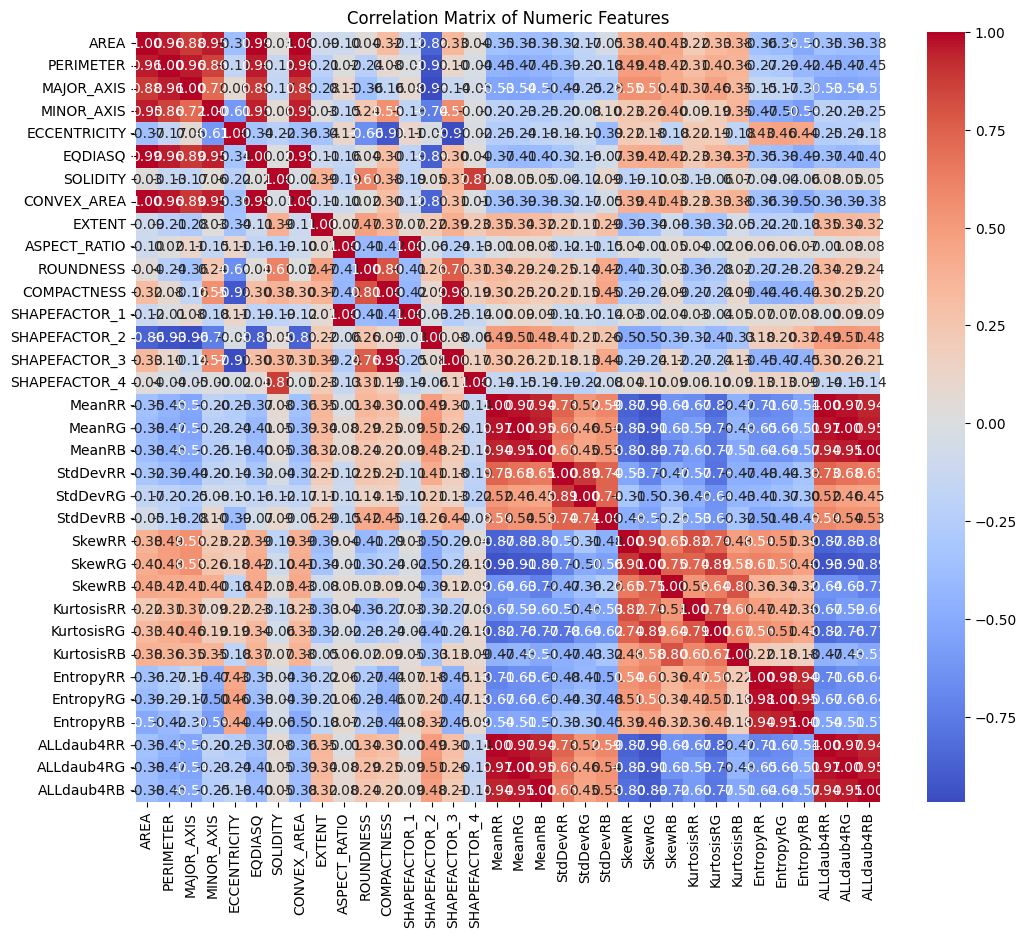

In [8]:
# prompt: select numeric columns beatiful correlation

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame (loaded from the Excel file as in your previous code)

# Select only numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns
numeric_df = df[numeric_cols]

# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

# Create a heatmap of the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numeric Features')
plt.show()


In [9]:
# prompt: check duplicates

import pandas as pd

# Assuming 'df' is your DataFrame (loaded from the Excel file as in your previous code)

# Check for duplicates based on all columns
duplicates = df[df.duplicated()]

# Print the duplicate rows
print("Duplicate Rows:")
print(duplicates)

# Number of duplicate rows
num_duplicates = len(duplicates)
print(f"\nNumber of duplicate rows: {num_duplicates}")

# Remove duplicates (optional)
# df_no_duplicates = df.drop_duplicates()

# Check for duplicates in specific columns (e.g., 'AREA', 'PERIMETER')
# duplicates_specific_cols = df[df.duplicated(subset=['AREA', 'PERIMETER'])]
# print("\nDuplicates based on 'AREA' and 'PERIMETER':")
# print(duplicates_specific_cols)


Duplicate Rows:
Empty DataFrame
Columns: [AREA, PERIMETER, MAJOR_AXIS, MINOR_AXIS, ECCENTRICITY, EQDIASQ, SOLIDITY, CONVEX_AREA, EXTENT, ASPECT_RATIO, ROUNDNESS, COMPACTNESS, SHAPEFACTOR_1, SHAPEFACTOR_2, SHAPEFACTOR_3, SHAPEFACTOR_4, MeanRR, MeanRG, MeanRB, StdDevRR, StdDevRG, StdDevRB, SkewRR, SkewRG, SkewRB, KurtosisRR, KurtosisRG, KurtosisRB, EntropyRR, EntropyRG, EntropyRB, ALLdaub4RR, ALLdaub4RG, ALLdaub4RB, Class]
Index: []

[0 rows x 35 columns]

Number of duplicate rows: 0


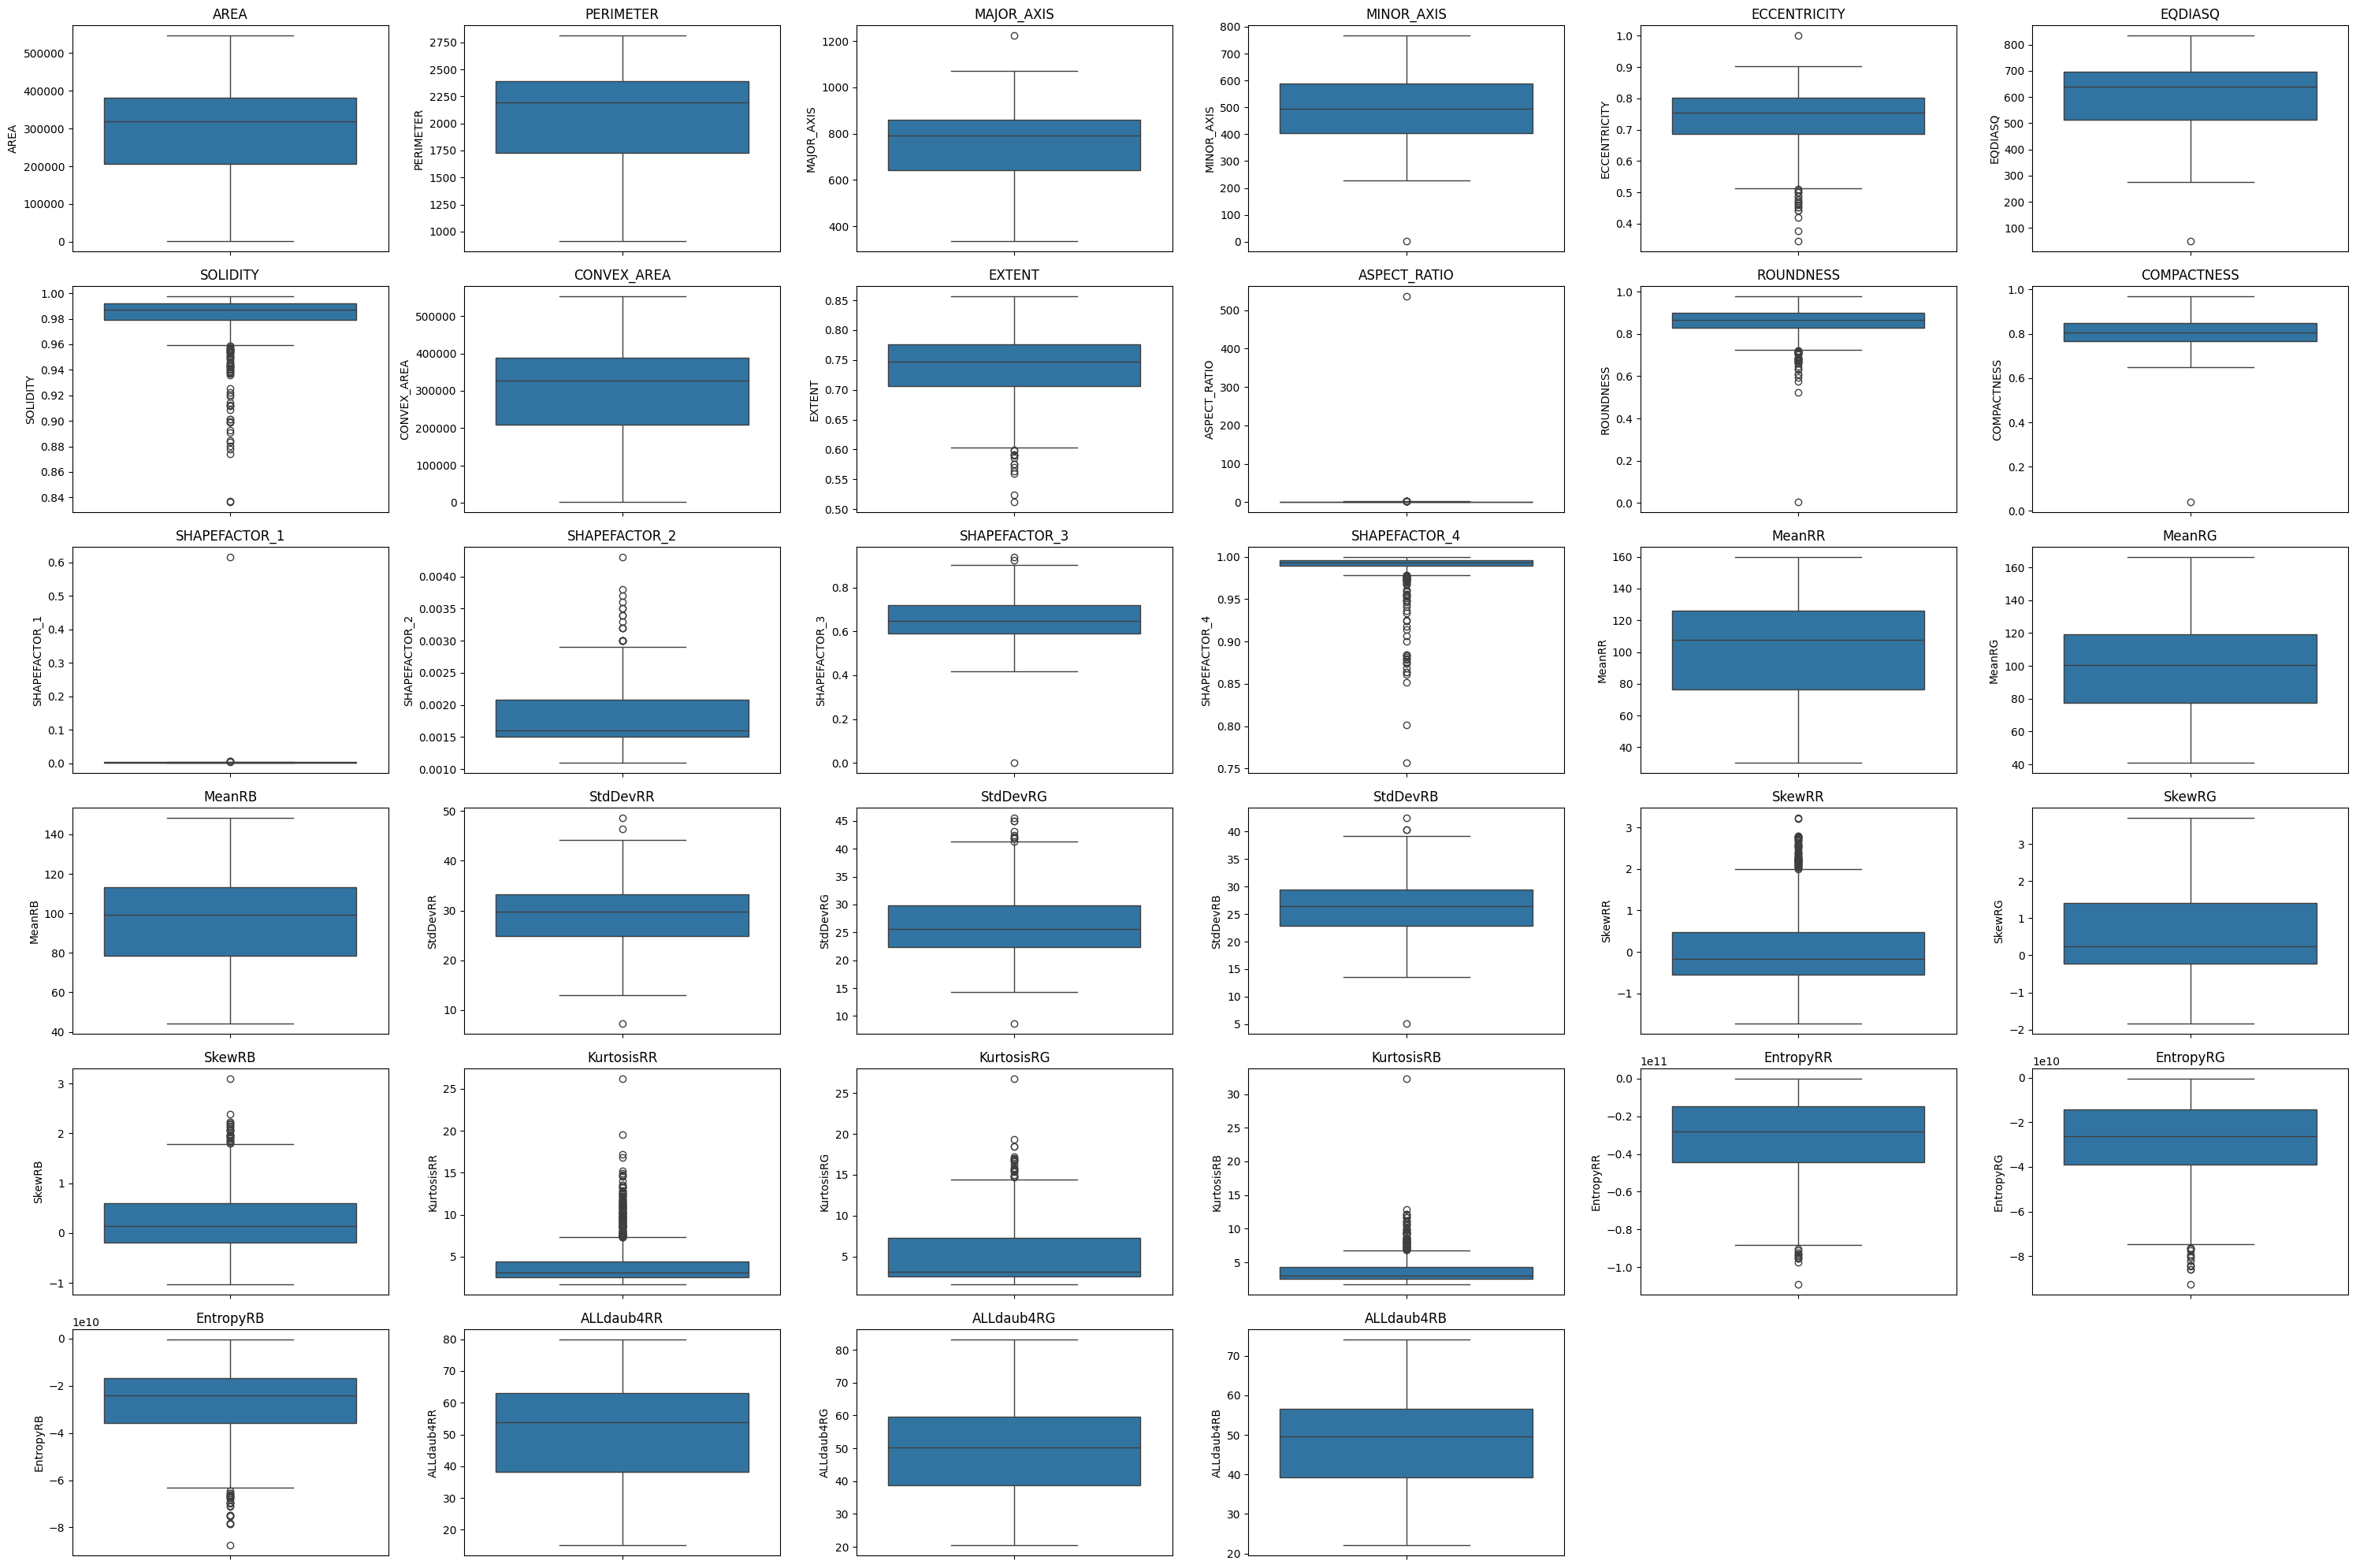

In [10]:
# prompt: boxplots columns

import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df' is your DataFrame and 'numeric_cols' contains the numeric column names

# Create boxplots for each numeric column
plt.figure(figsize=(30, 20))  # Adjust figure size as needed
for i, col in enumerate(numeric_cols):
    plt.subplot(6, 6, i + 1)  # Adjust subplot grid if necessary
    sns.boxplot(y=df[col])
    plt.title(col)
    plt.tight_layout()  # Improve spacing between subplots

plt.show()


In [11]:
from scipy import stats

# Define function to remove outliers using Z-score
def remove_outliers_zscore(df, threshold=3):
    z_scores = np.abs(stats.zscore(df[numeric_cols]))
    return df[(z_scores < threshold).all(axis=1)]

# Apply function
df = remove_outliers_zscore(df)
df


,AREA,PERIMETER,MAJOR_AXIS,MINOR_AXIS,ECCENTRICITY,EQDIASQ,SOLIDITY,CONVEX_AREA,EXTENT,ASPECT_RATIO,...,KurtosisRR,KurtosisRG,KurtosisRB,EntropyRR,EntropyRG,EntropyRB,ALLdaub4RR,ALLdaub4RG,ALLdaub4RB,Class
0,422163,2378.9080,837.8484,645.6693,0.6373,733.1539,0.9947,424428,0.7831,1.2976,...,3.2370,2.9574,4.2287,-59191263232,-50714214400,-39922372608,58.7255,54.9554,47.8400,BERHI
1,338136,2085.1440,723.8198,595.2073,0.5690,656.1464,0.9974,339014,0.7795,1.2161,...,2.6228,2.6350,3.1704,-34233065472,-37462601728,-31477794816,50.0259,52.8168,47.8315,BERHI
3,416063,2351.2100,827.9804,645.2988,0.6266,727.8378,0.9948,418255,0.7759,1.2831,...,5.0401,8.6136,8.2618,-32074307584,-32060925952,-29575010304,43.3900,44.1259,41.1882,BERHI
4,347562,2160.3540,763.9877,582.8359,0.6465,665.2291,0.9908,350797,0.7569,1.3108,...,2.7016,2.9761,4.4146,-39980974080,-35980042240,-25593278464,52.7743,50.9080,42.6666,BERHI
5,408953,2326.6931,840.1821,622.0076,0.6722,721.5921,0.9974,410036,0.7805,1.3508,...,3.6309,6.0285,6.2159,-41140371456,-33146710016,-27907301376,49.7001,45.3190,39.7371,BERHI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
893,255403,1925.3650,691.8453,477.1796,0.7241,570.2536,0.9785,261028,0.7269,1.4499,...,2.2423,2.3704,2.7202,-25296416768,-19168882688,-18473392128,49.0869,43.0422,42.4153,SOGAY
894,365924,2664.8230,855.4633,551.5447,0.7644,682.5752,0.9466,386566,0.6695,1.5510,...,3.4109,3.5805,3.9910,-31605219328,-21945366528,-19277905920,46.8086,39.1046,36.5502,SOGAY
895,254330,1926.7360,747.4943,435.6219,0.8126,569.0545,0.9925,256255,0.7240,1.7159,...,2.2759,2.5090,2.6951,-22242772992,-19594921984,-17592152064,44.1325,40.7986,40.9769,SOGAY
896,238955,1906.2679,716.6485,441.8297,0.7873,551.5859,0.9604,248795,0.6954,1.6220,...,2.6769,2.6874,2.7991,-26048595968,-21299822592,-19809978368,51.2267,45.7162,45.6260,SOGAY


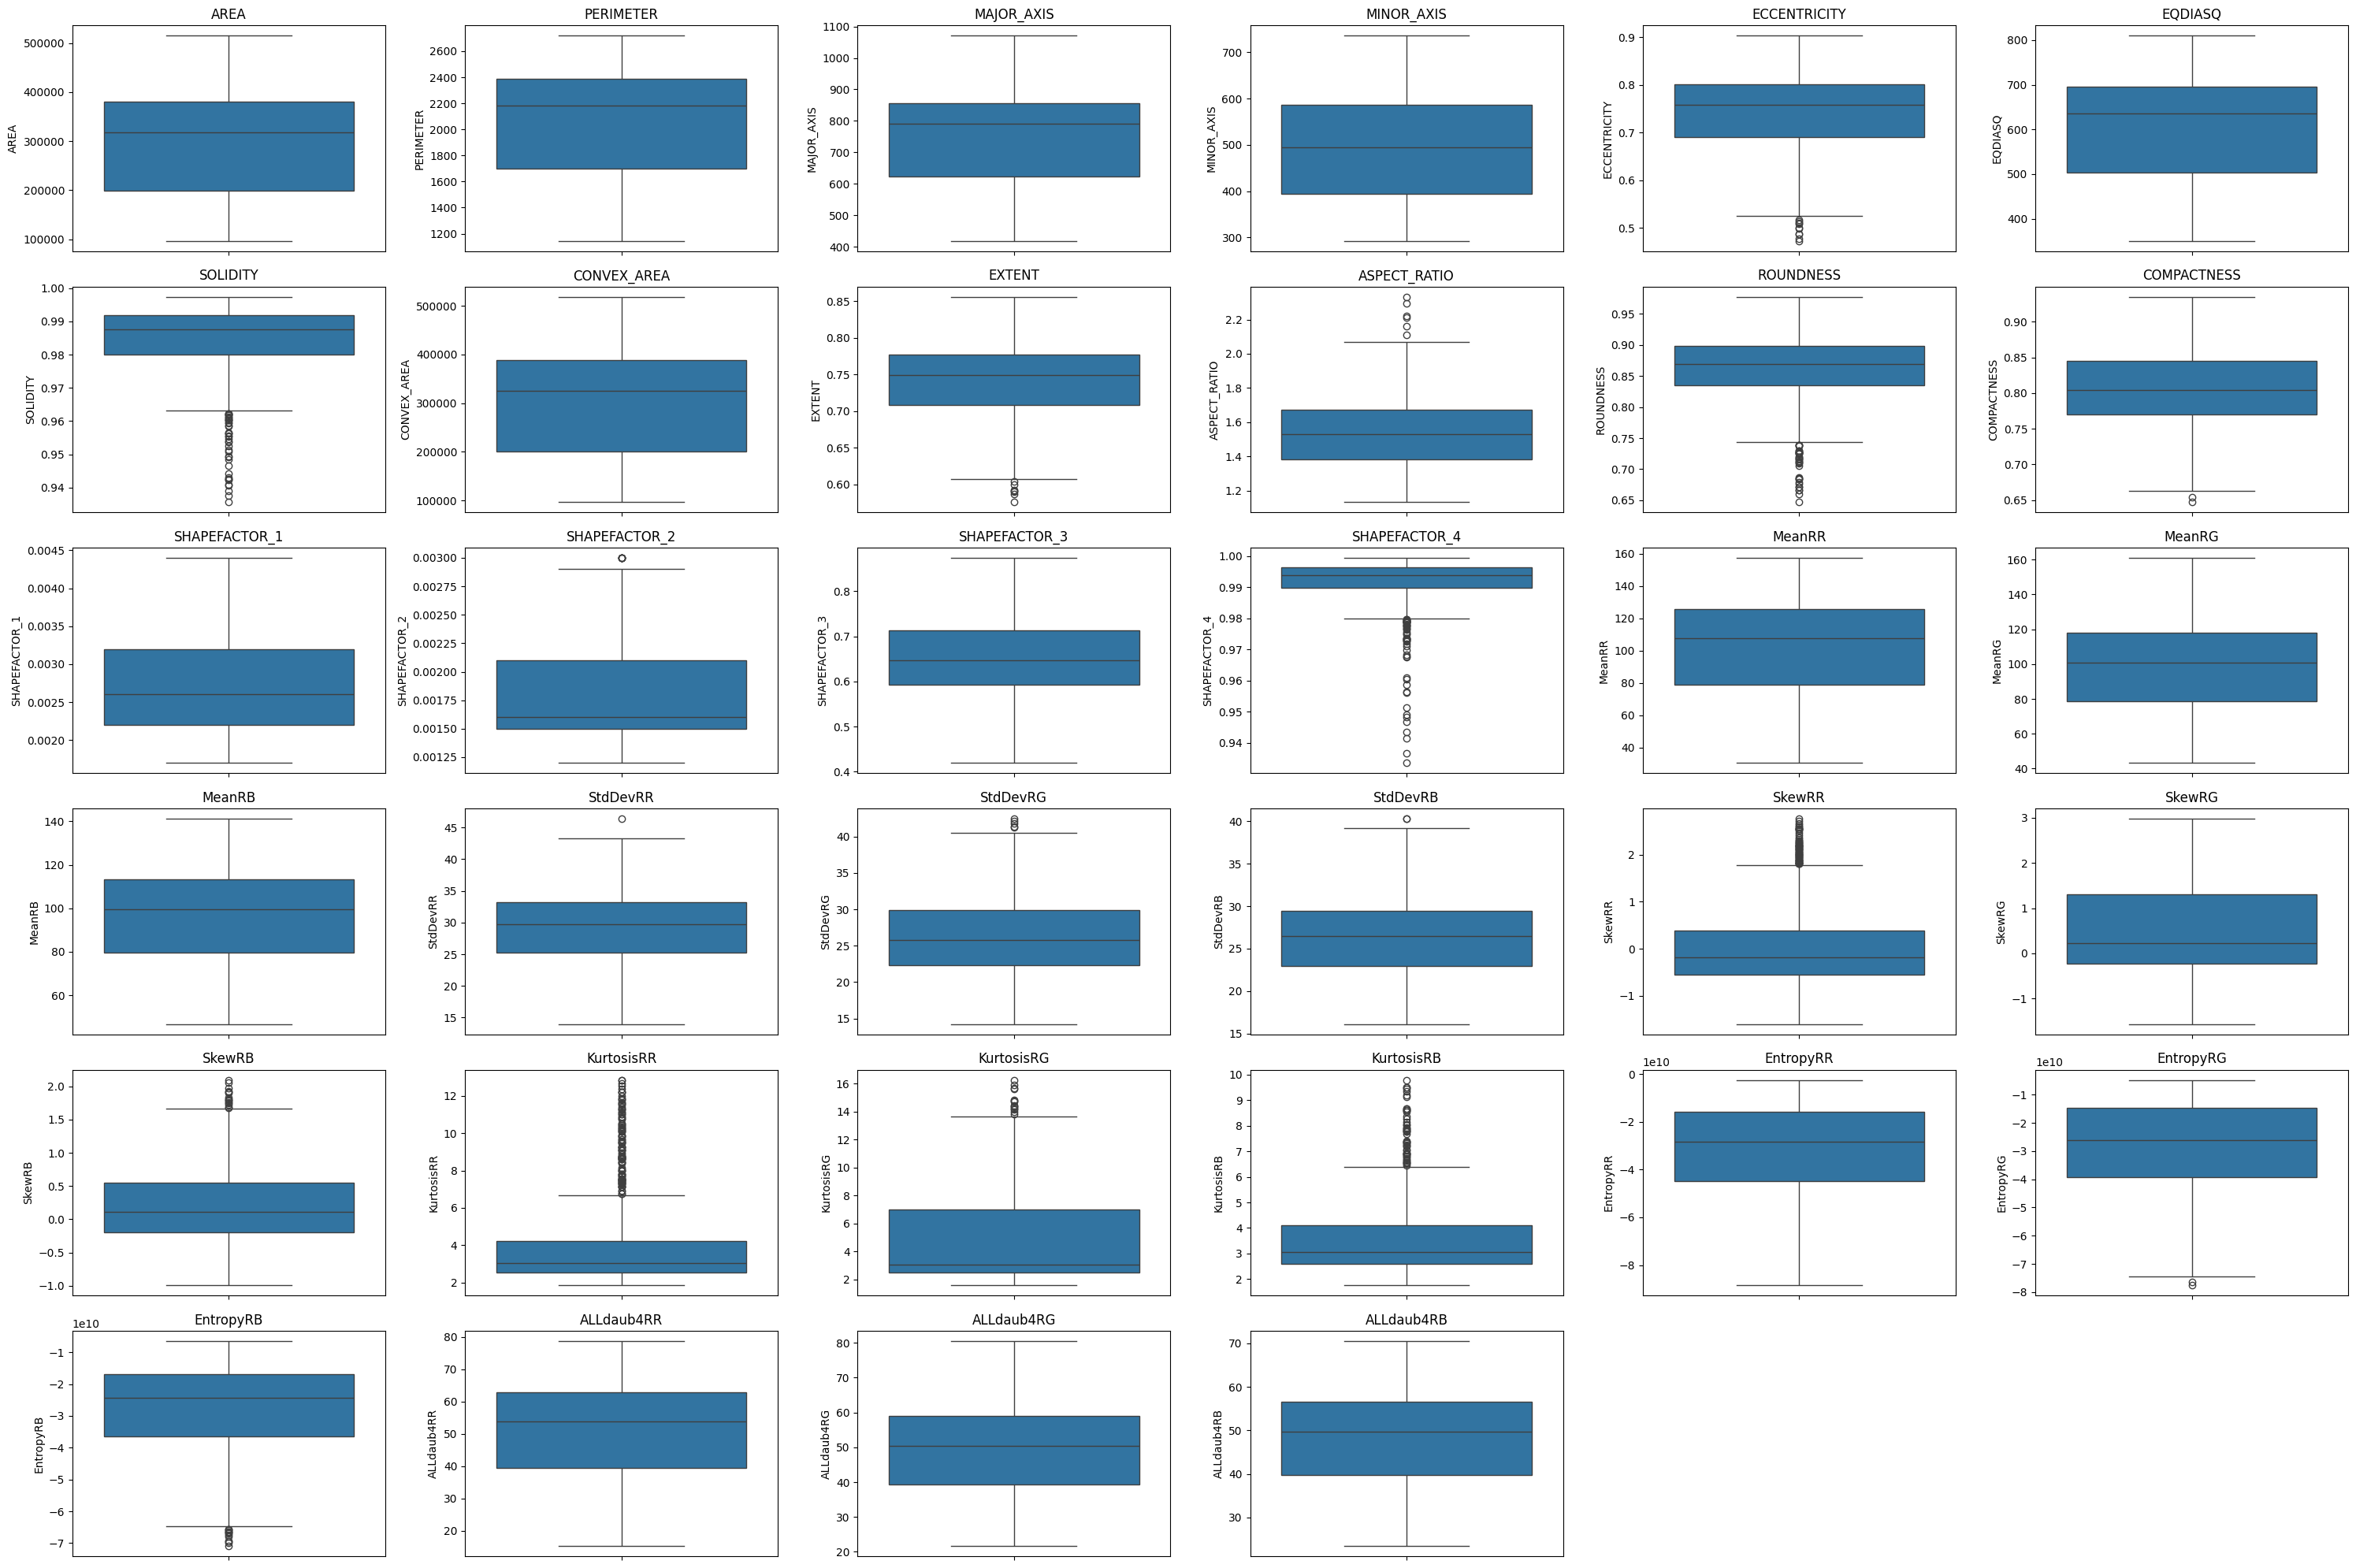

In [12]:
# prompt: boxplots columns

import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df' is your DataFrame and 'numeric_cols' contains the numeric column names

# Create boxplots for each numeric column
plt.figure(figsize=(30, 20))  # Adjust figure size as needed
for i, col in enumerate(numeric_cols):
    plt.subplot(6, 6, i + 1)  # Adjust subplot grid if necessary
    sns.boxplot(y=df[col])
    plt.title(col)
    plt.tight_layout()  # Improve spacing between subplots

plt.show()


In [13]:
# prompt: encode class column

from sklearn.preprocessing import LabelEncoder

# Assuming 'df' is your DataFrame and 'Class' is the column to encode
le = LabelEncoder()
df['Class'] = le.fit_transform(df['Class'])

print(df['Class'].unique())


[0 1 2 3 4 5 6]


<ipython-input-13-b75b238874ca>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Class'] = le.fit_transform(df['Class'])


In [33]:
# prompt: trai test split

# Assuming 'df' is your DataFrame after outlier removal

# Separate features (X) and target variable (y)
X = df.drop('Class', axis=1)  # Replace 'Class' with the actual name of your target column
y = df['Class']
# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the numeric columns
X = scaler.fit_transform(X)
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Adjust test_size as needed


XGBoost Train: 1.0
XGBoost Test: 0.8930817610062893
XGBoost Accuracy: 0.8930817610062893
              precision    recall  f1-score   support

           0       0.70      0.70      0.70        10
           1       0.74      0.85      0.79        20
           2       0.94      0.91      0.92        33
           3       0.77      0.83      0.80        12
           4       1.00      0.94      0.97        32
           5       1.00      1.00      1.00        36
           6       0.80      0.75      0.77        16

    accuracy                           0.89       159
   macro avg       0.85      0.85      0.85       159
weighted avg       0.90      0.89      0.89       159



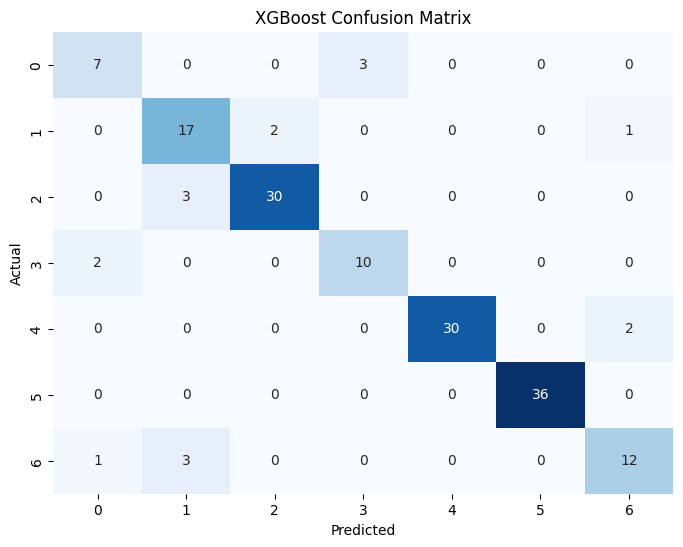

In [34]:
# prompt: xgboost model

import matplotlib.pyplot as plt
# Assuming X_train, X_test, y_train, y_test are defined as in your previous code

import xgboost as xgb

# Create an XGBoost classifier
xgb_model = xgb.XGBClassifier(objective='multi:softmax', num_class=len(y_train.unique()), random_state=42)

# Train the model
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the model
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Train: {xgb_model.score(X_train,y_train)}")
print(f"XGBoost Test: {xgb_model.score(X_test,y_test)}")
print(f"XGBoost Accuracy: {accuracy_xgb}")
print(classification_report(y_test, y_pred_xgb))

# Confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.show()


Random Forest Train: 1.0
Random Forest Test: 0.8930817610062893
Random Forest Accuracy: 0.8930817610062893
              precision    recall  f1-score   support

           0       1.00      0.70      0.82        10
           1       0.73      0.80      0.76        20
           2       0.94      0.91      0.92        33
           3       0.80      1.00      0.89        12
           4       0.97      0.94      0.95        32
           5       1.00      0.97      0.99        36
           6       0.71      0.75      0.73        16

    accuracy                           0.89       159
   macro avg       0.88      0.87      0.87       159
weighted avg       0.90      0.89      0.89       159



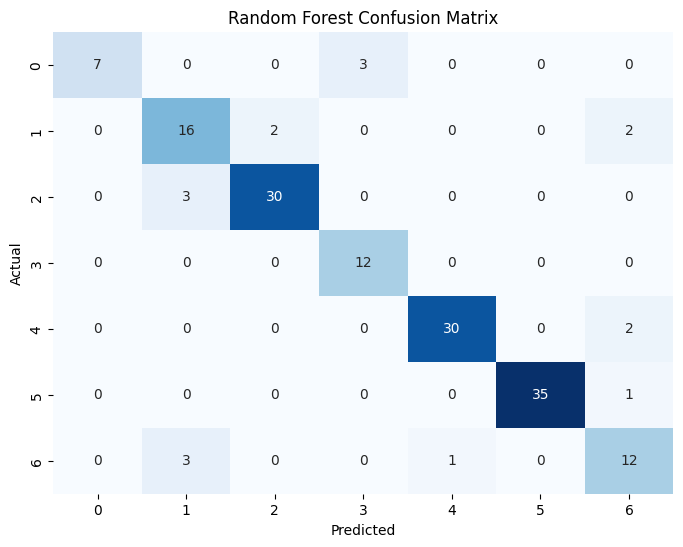

In [35]:
# prompt: Random Forest model like up code

import matplotlib.pyplot as plt
# Assuming X_train, X_test, y_train, y_test are defined as in your previous code

# Create a Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42) # You can adjust n_estimators

# Train the classifier
rf_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_classifier.predict(X_test)

# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Train: {rf_classifier.score(X_train,y_train)}")
print(f"Random Forest Test: {rf_classifier.score(X_test,y_test)}")
print(f"Random Forest Accuracy: {accuracy_rf}")
print(classification_report(y_test, y_pred_rf))

# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000311 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6692
[LightGBM] [Info] Number of data points in the train set: 634, number of used features: 34
[LightGBM] [Info] Start training from score -2.763170
[LightGBM] [Info] Start training from score -2.175383
[LightGBM] [Info] Start training from score -1.402193
[LightGBM] [Info] Start training from score -2.520223
[LightGBM] [Info] Start training from score -1.664557
[LightGBM] [Info] Start training from score -1.569247
[LightGBM] [Info] Start training from score -2.308914
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


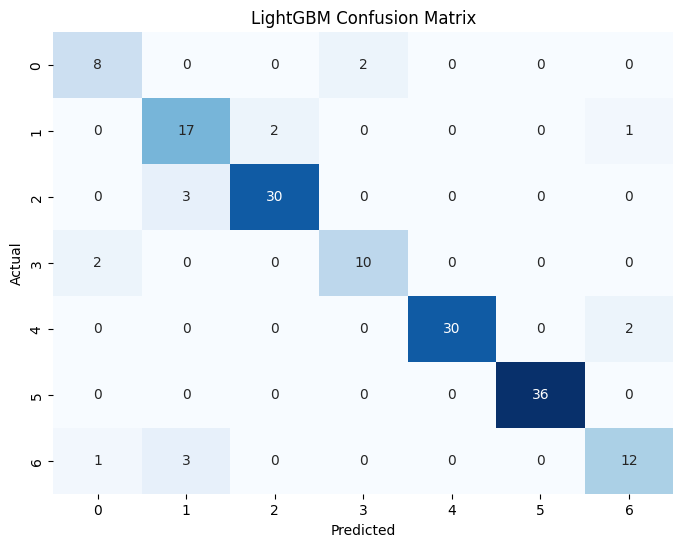

In [36]:
# prompt: light gbm model like up code

import matplotlib.pyplot as plt
import lightgbm as lgb

# Assuming X_train, X_test, y_train, y_test are defined as in your previous code

# Create a LightGBM classifier
lgb_model = lgb.LGBMClassifier(objective='multiclass', num_class=len(y_train.unique()), random_state=42)

# Train the model
lgb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lgb = lgb_model.predict(X_test)

# Evaluate the model
accuracy_lgb = accuracy_score(y_test, y_pred_lgb)
print(f"LightGBM Train: {lgb_model.score(X_train, y_train)}")
print(f"LightGBM Test: {lgb_model.score(X_test, y_test)}")
print(f"LightGBM Accuracy: {accuracy_lgb}")
print(classification_report(y_test, y_pred_lgb))

# Confusion matrix
cm_lgb = confusion_matrix(y_test, y_pred_lgb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lgb, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LightGBM Confusion Matrix")
plt.show()


Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 125ms/step - accuracy: 0.5187 - loss: 1.6844 - val_accuracy: 0.6406 - val_loss: 0.8278
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7372 - loss: 0.6723 - val_accuracy: 0.8438 - val_loss: 0.4199
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8870 - loss: 0.3634 - val_accuracy: 0.8438 - val_loss: 0.4664
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8780 - loss: 0.3512 - val_accuracy: 0.8906 - val_loss: 0.4041
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8818 - loss: 0.2951 - val_accuracy: 0.8906 - val_loss: 0.2481
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9162 - loss: 0.2197 - val_accuracy: 0.9219 - val_loss: 0.2530
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9154 - loss: 0.1779 - val_accuracy: 0.8906 - val_loss: 0.2783
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9361 - loss: 0.1616 - val_accuracy: 0.8906 - val_los

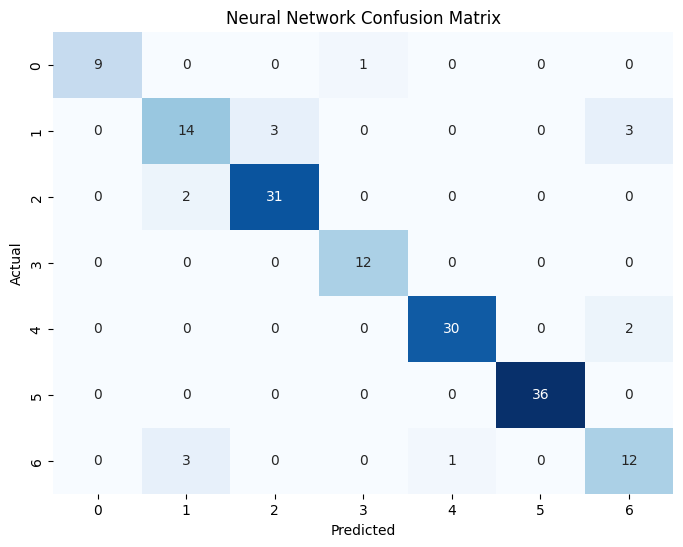

In [40]:
# prompt: neural network model like up code

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Assuming X_train, X_test, y_train, y_test are defined as in your previous code

# Define the model
model = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(X_train.shape[1],)),  # Input layer
    layers.Dense(128, activation='relu'),  # Input layer
    layers.Dense(128, activation='relu'),  # Input layer
    layers.Dense(64, activation='relu'),  # Input layer
    layers.Dense(64, activation='relu'),  # Input layer
    layers.Dense(32, activation='relu'),  # Input layer
    # layers.Dropout(0.2), #Dropout layer to prevent overfitting
    # layers.Dropout(0.2),
    layers.Dense(len(y_train.unique()), activation='softmax')  # Output layer with softmax for multi-class classification
])

# Compile the model
sgd = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',  # Use sparse categorical crossentropy for integer labels
              metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1) # Adjust epochs and batch size as needed


# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")


# Make predictions
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Generate classification report
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Neural Network Confusion Matrix")
plt.show()
